<a href="https://colab.research.google.com/github/Betancur97/python-a-fondo/blob/master/ProcesamientoTemperatura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

funciones


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans


def ReadCSV(ruta):
  df = pd.read_csv(ruta, sep=";", skiprows=23)
  return df


def Plotear(x, y, titulo, ejeX, ejeY):
  plt.figure(figsize=(8, 5))
  sns.lineplot(x=x, y=y, color="blue")
  plt.title(titulo)
  plt.xlabel(ejeX)
  plt.ylabel(ejeY)
  plt.grid(True)
  plt.tight_layout()
  plt.show()


def PlotearDosLineas(x, y1, y2, label1, label2, titulo, ejeX, ejeY):
    plt.figure(figsize=(8, 5))
    sns.lineplot(x=x, y=y1, color="blue", label=label1)
    sns.lineplot(x=x, y=y2, color="orange", label=label2)
    plt.title(titulo)
    plt.xlabel(ejeX)
    plt.ylabel(ejeY)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def PotenciaRecuperada(FlujoMasico, CnstCalorica, TemperaturaEntrada, TemperaturaSalida):
  Qe = []
  C=[]
  aux=0
  for i in range(len(TemperaturaEntrada)):
    t_in = (
        TemperaturaEntrada.iloc[i]
        if isinstance(TemperaturaEntrada, pd.Series)
        else TemperaturaEntrada[i]
    )
    t_out = (
        TemperaturaSalida.iloc[i]
        if isinstance(TemperaturaSalida, pd.Series)
        else TemperaturaSalida[i]
    )
    q = FlujoMasico * CnstCalorica * (t_out - t_in)
    c=aux/q
    if q < 0:
      q = 0
    aux=q
    Qe.append(q)
    C.append(c)
  return Qe


def PotenciaEntrada(temp1, temp2):
  tempPromedio = (temp1 + temp2) / 2
  X = (
      tempPromedio.rolling(window=30, center=True, min_periods=1)
      .mean()
      .values.reshape(-1, 1)
  )
  y = np.array([0, 10, 20, 30, 40, 50])

  kmeans = KMeans(n_clusters=len(y), random_state=42, n_init=10)
  clusters = kmeans.fit_predict(X)

  centros = kmeans.cluster_centers_.flatten()
  ordenClusters = np.argsort(centros)

  potenciasEvap = y
  mapaPotencias = np.zeros(len(y))

  for i, idx_original in enumerate(ordenClusters):
    if i < len(y):
      mapaPotencias[idx_original] = potenciasEvap[i]

  potenciaEstimada = [mapaPotencias[c] for c in clusters]

  potenciasEvapList = []
  pMax = 0
  for p in potenciaEstimada:
    if p > pMax:
      pMax = p
    potenciasEvapList.append(pMax)

  return potenciasEvapList


def Eficiencia(Qin, Qout):
  n = []
  QoAnt = 0
  for i in range(len(Qout)):
    q_in = Qin[i] if not isinstance(Qin, pd.Series) else Qin.iloc[i]
    q_out = Qout[i] if not isinstance(Qout, pd.Series) else Qout.iloc[i]
    #q_out_A=Qout[i-1]

    if q_out > 0 and q_in > 0:
      eff = 100 * (q_out / (Qout[i-1]+q_in))
    else:
      eff = 0.0
    #QoAnt = q_out
    n.append(eff)
  return n

def PotenciaRealSalida(ef, Qin):
  potenciaReal=[]
  potR=0
  for i in range(len(ef)):
    potR=ef[i]*Qin[i]/100
    if potR>0:
      potenciaReal.append(potR)
    else:
      potenciaReal.append(0)
  return potenciaReal


def ResistenciaTermica(tempEvapProm, tempCondProm, Qe):
  R = []
  for i in range(len(Qe)):
    q = Qe[i] if not isinstance(Qe, pd.Series) else Qe.iloc[i]
    tEvap = (
        tempEvapProm[i]
        if not isinstance(tempEvapProm, pd.Series)
        else tempEvapProm.iloc[i]
    )
    tCond = (
        tempCondProm[i]
        if not isinstance(tempCondProm, pd.Series)
        else tempCondProm.iloc[i]
    )

    dt = tEvap - tCond
    r = (dt / q) if q != 0 else 0.0
    R.append(r)
  return R

def PlotearMultiplesGraficas(x, lista_variables,listaLabel1, listaLabel2, titulo_general):

    """
    Plotea múltiples variables en subgráficos apilados verticalmente compartiendo el eje X.

    Parámetros:
    - x: Serie o arreglo del tiempo.
    - lista_variables: Lista de diccionarios con las llaves: 'y', 'ylabel', 'titulo', 'color'.
    - titulo_general: Título principal de la figura completa.
    """
    n = len(lista_variables)
    # Creamos una figura con 'n' filas, compartiendo el eje X (sharex=True)
    fig, axes = plt.subplots(n, 1, figsize=(10, 2.5 * n), sharex=True)

    # Asegurar iteración correcta si solo se pasa una variable
    if n == 1:
        axes = [axes]

    for i, var in enumerate(lista_variables):
        sns.lineplot(x=x, y=var["y"], ax=axes[i], color=var.get("color", "blue"))
        axes[i].set_title(var["titulo"], fontsize=11)
        axes[i].set_ylabel(var["ylabel"], fontsize=10)
        axes[i].grid(True)

    # Asignar etiqueta al eje X solo en la última gráfica inferior
    axes[-1].set_xlabel("Tiempo (s)", fontsize=11)

    plt.suptitle(titulo_general, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # --- 1. FUNCIÓN DEL FILTRO DE KALMAN ---
def FiltroKalman1D(z, q=1e-5, r=5e-2):
    """
    Aplica un filtro de Kalman 1D a una serie de datos ruidosos.
    - q: Varianza del proceso (valores más pequeños = mayor suavizado).
    - r: Varianza de la medición (ruido del sensor).
    """
    if isinstance(z, pd.Series):
        z_vals = z.values
    else:
        z_vals = np.array(z)

    n = len(z_vals)
    if n == 0:
        return z

    x_est = z_vals[0]
    p = 1.0

    filtrados = []
    for medida in z_vals:
        x_pred = x_est
        p_pred = p + q

        k = p_pred / (p_pred + r)
        x_est = x_pred + k * (medida - x_pred)
        p = (1 - k) * p_pred

        filtrados.append(x_est)

    if isinstance(z, pd.Series):
        return pd.Series(filtrados, index=z.index)
    return np.array(filtrados)




Instanciamos la funciones con la toma de datos del termosifon  3/16"

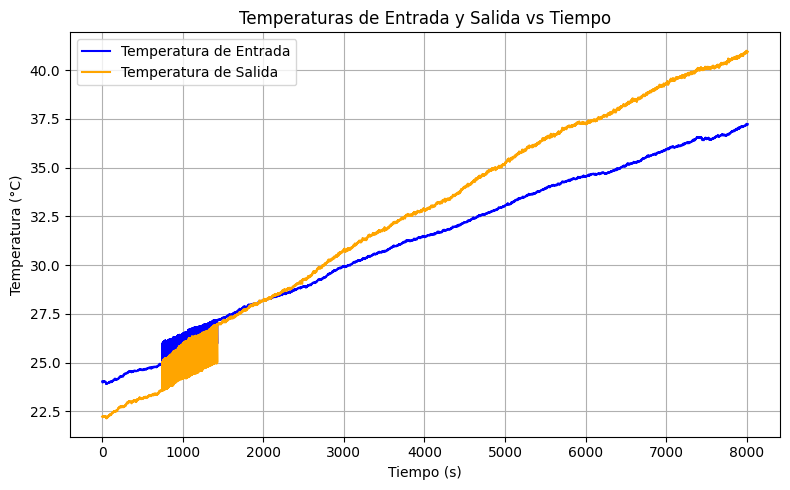

----------------------------------------------------------------------
----------------------------------------------------------------------


/tmp/ipykernel_818/3838735061.py:52: RuntimeWarning: invalid value encountered in scalar divide
  c=aux/q
/tmp/ipykernel_818/3838735061.py:52: RuntimeWarning: divide by zero encountered in scalar divide
  c=aux/q


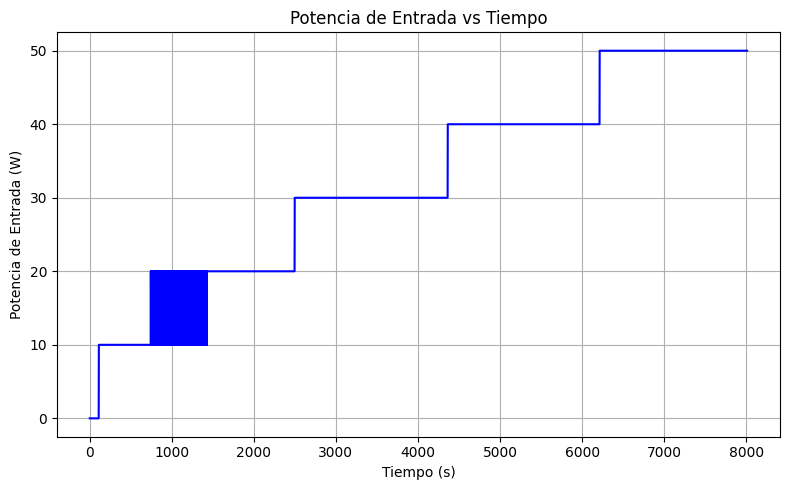

----------------------------------------------------------------------


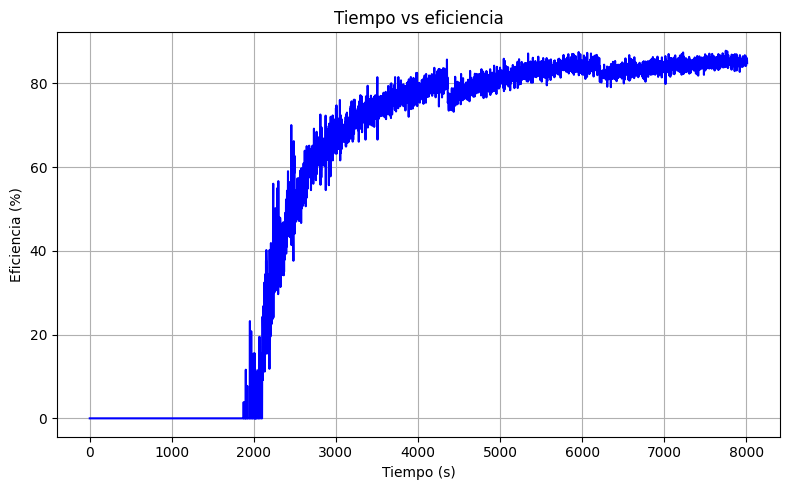

----------------------------------------------------------------------


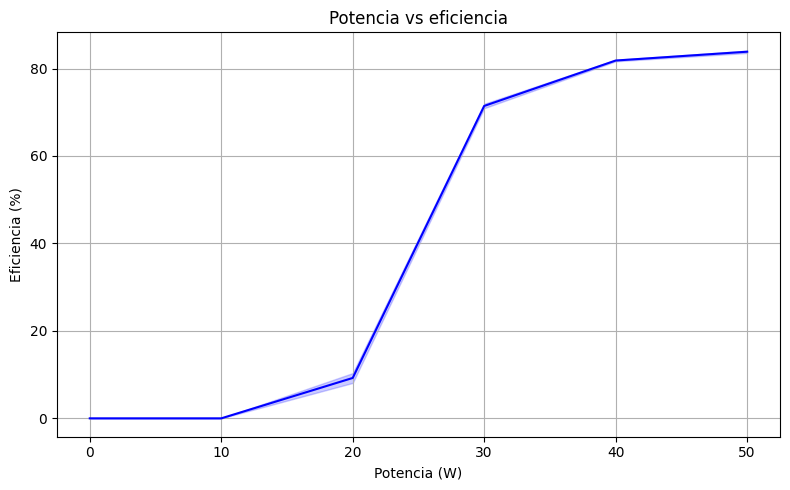

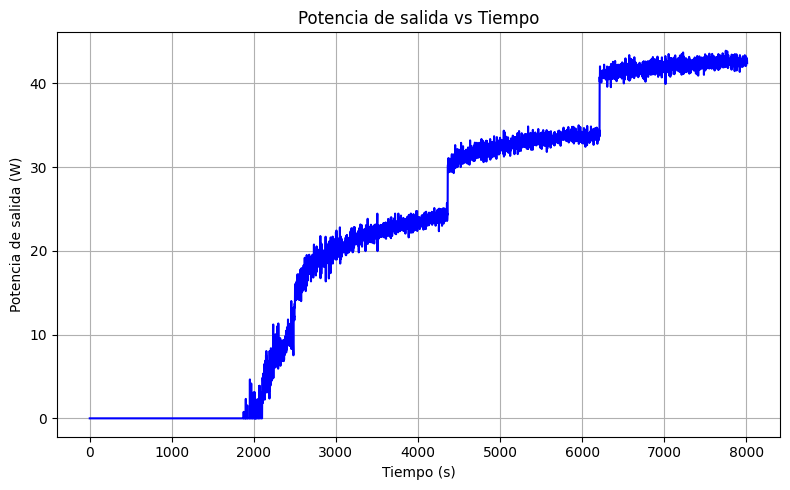

----------------------------------------------------------------------
      Temperatura de entrada  Temperatura de salida  Potencia Entrada  \
0                      24.03                  22.23               0.0   
1                      23.99                  22.21               0.0   
2                      23.99                  22.20               0.0   
3                      23.99                  22.21               0.0   
4                      23.98                  22.21               0.0   
...                      ...                    ...               ...   
4342                   37.20                  40.91              50.0   
4343                   37.20                  40.94              50.0   
4344                   37.23                  40.95              50.0   
4345                     NaN                    NaN              50.0   
4346                     NaN                    NaN              50.0   

      Eficiencia  Potencia de salida  
0       0.000

In [ ]:
# Lectura de la base de datos
ruta = "/content/Prueba_26_08.csv"
BaseDatos = ReadCSV(ruta)

x = BaseDatos["Tiempo (s)"]

# Asignar nombres claros a las temperaturas de entrada y salida
BaseDatos["Temperatura de entrada"] = BaseDatos["Canal 1 (°C)"]
BaseDatos["Temperatura de salida"] = BaseDatos["Canal 2 (°C)"]

tempEntrada = BaseDatos["Temperatura de entrada"]
tempSalida = BaseDatos["Temperatura de salida"]

# Graficar ambas temperaturas juntas para comparar su comportamiento
PlotearDosLineas(
    x,
    tempEntrada,

    tempSalida,
    "Temperatura de Entrada",
    "Temperatura de Salida",
    "Temperaturas de Entrada y Salida vs Tiempo",
    "Tiempo (s)",
    "Temperatura (°C)",
)
print("----------------------------------------------------------------------")

# Cálculo de la Potencia Recuperada
flujoMasico = 18.5
cp = 4.184

BaseDatos["Potencia recuperada"] = PotenciaRecuperada(
    flujoMasico, cp, tempEntrada, tempSalida
)
Qe = BaseDatos["Potencia recuperada"]
#Plotear(x, Qe, "Potencia Recuperada vs Tiempo", "Tiempo (s)", "Potencia Recuperada (W)")
print("----------------------------------------------------------------------")

# Cálculo de la Potencia de Entrada (Uso de Canal 5 y Canal 6)
BaseDatos["Potencia Entrada"] = PotenciaEntrada(
    BaseDatos["Canal 5 (°C)"], BaseDatos["Canal 6 (°C)"]
)
Qin = BaseDatos["Potencia Entrada"]
Plotear(x, Qin, "Potencia de Entrada vs Tiempo", "Tiempo (s)", "Potencia de Entrada (W)")
print("----------------------------------------------------------------------")

# Cálculo de la Eficiencia
BaseDatos["Eficiencia"] = Eficiencia(Qin, Qe)
eficiencia = BaseDatos["Eficiencia"]
Plotear(x, eficiencia, "Tiempo vs eficiencia", "Tiempo (s)", "Eficiencia (%)")
print("----------------------------------------------------------------------")

Plotear(Qin, eficiencia, "Potencia vs eficiencia", "Potencia (W)", "Eficiencia (%)")

#Potencia de salida

potenciaSalida=PotenciaRealSalida(eficiencia,Qin)
BaseDatos["Potencia de salida"]=potenciaSalida
Plotear(x, potenciaSalida, "Potencia de salida vs Tiempo", "Tiempo (s)", "Potencia de salida (W)")
print("----------------------------------------------------------------------")



# Cálculo de la Resistencia Térmica
tempCondProm = (BaseDatos["Canal 3 (°C)"] + BaseDatos["Canal 4 (°C)"]) / 2
tempEvapProm = (BaseDatos["Canal 5 (°C)"] + BaseDatos["Canal 6 (°C)"]) / 2
BaseDatos["Resistencia_Termica (°C/W)"] = ResistenciaTermica(
    tempEvapProm, tempCondProm, Qe
)

# Mostrar únicamente las columnas seleccionadas en el print final
columnas_deseadas = [
    "Temperatura de entrada",
    "Temperatura de salida",
    "Potencia Entrada",
    "Eficiencia",
    "Potencia de salida"
]

print(BaseDatos[columnas_deseadas])
B1=BaseDatos[columnas_deseadas]

aplicamos un filtro kalman a los sensores de temperatura  

---



Offset detectado entre sensores a 0 W: -1.777 °C


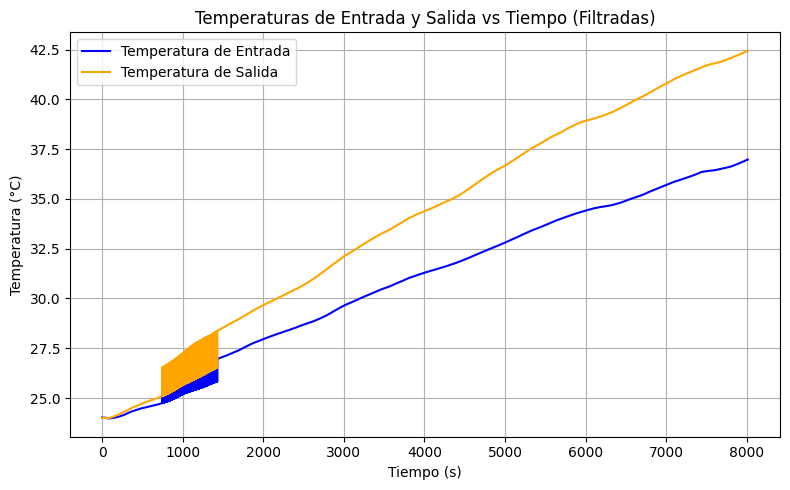

----------------------------------------------------------------------
----------------------------------------------------------------------
----------------------------------------------------------------------


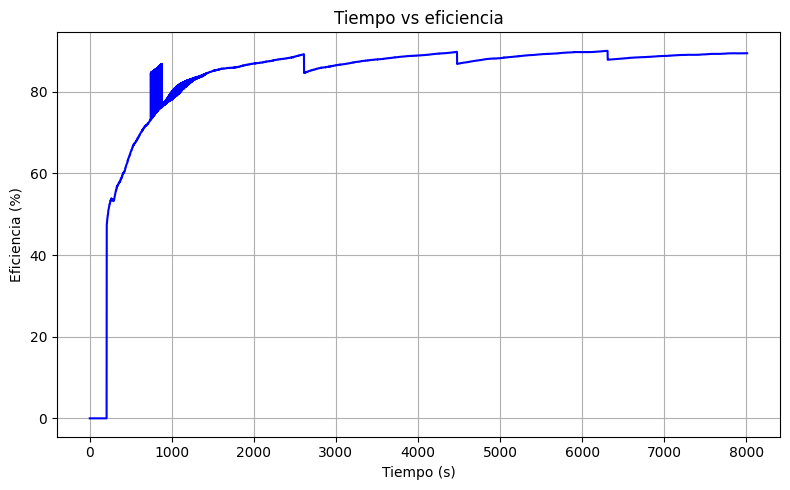

----------------------------------------------------------------------
----------------------------------------------------------------------


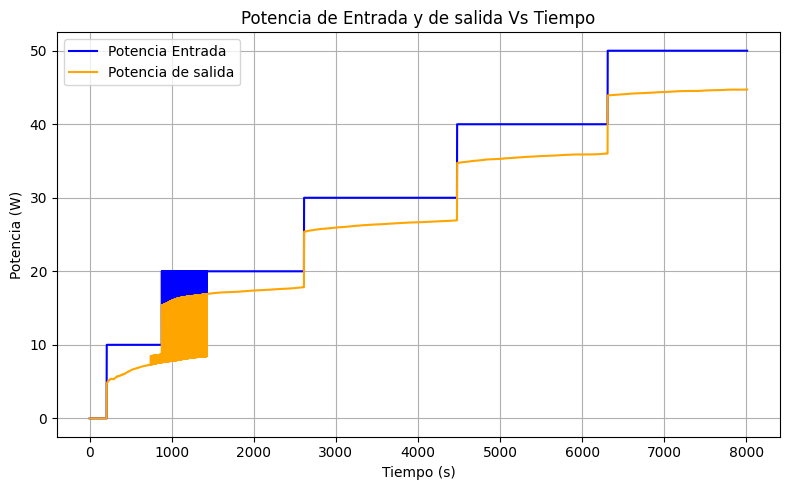

      Temperatura de entrada  Temperatura de salida  Potencia Entrada  \
0                  24.030000              24.006595               0.0   
1                  24.010486              23.996838               0.0   
2                  24.003767              23.990198               0.0   
3                  24.000365              23.989308               0.0   
4                  23.996327              23.988770               0.0   
...                      ...                    ...               ...   
4342               36.969423              42.434571              50.0   
4343               36.972661              42.438531              50.0   
4344               36.976275              42.442576              50.0   
4345                     NaN                    NaN              50.0   
4346                     NaN                    NaN              50.0   

      Eficiencia  Potencia de salida  Temperatura evaporador  
0       0.000000            0.000000               28.540000

In [ ]:
ruta = "/content/Prueba_26_08.csv"
BaseDatos = ReadCSV(ruta)

x = BaseDatos["Tiempo (s)"]

# --- APLICAR FILTRO DE KALMAN A LOS CANALES DE TEMPERATURA ---
BaseDatos["Canal 1_filt"] = FiltroKalman1D(BaseDatos["Canal 1 (°C)"])
BaseDatos["Canal 2_filt"] = FiltroKalman1D(BaseDatos["Canal 2 (°C)"])
BaseDatos["Canal 3_filt"] = FiltroKalman1D(BaseDatos["Canal 3 (°C)"])
BaseDatos["Canal 4_filt"] = FiltroKalman1D(BaseDatos["Canal 4 (°C)"])
BaseDatos["Canal 5_filt"] = FiltroKalman1D(BaseDatos["Canal 5 (°C)"])
BaseDatos["Canal 6_filt"] = FiltroKalman1D(BaseDatos["Canal 6 (°C)"])

# --- 3. CORRECCIÓN DE DESFASE INICIAL (CALIBRACIÓN DE SENSORES) ---
n_puntos_reposo = 50
offset_inicial = (
    BaseDatos["Canal 2_filt"].iloc[:n_puntos_reposo]
    - BaseDatos["Canal 1_filt"].iloc[:n_puntos_reposo]
).mean()
print(f"Offset detectado entre sensores a 0 W: {offset_inicial:.3f} °C")

# Asignar nombres claros utilizando los canales filtrados
BaseDatos["Temperatura de entrada"] = BaseDatos["Canal 1_filt"]
BaseDatos["Temperatura de salida"] = BaseDatos["Canal 2_filt"] - offset_inicial

tempEntrada = BaseDatos["Temperatura de entrada"]
tempSalida = BaseDatos["Temperatura de salida"]

BaseDatos["Temperatura evaporador"] = (BaseDatos["Canal 5_filt"]+BaseDatos["Canal 6_filt"])/2

# Graficar ambas temperaturas juntas para comparar su comportamiento
PlotearDosLineas(
    x,
    tempEntrada,
    tempSalida,
    "Temperatura de Entrada",
    "Temperatura de Salida",
    "Temperaturas de Entrada y Salida vs Tiempo (Filtradas)",
    "Tiempo (s)",
    "Temperatura (°C)",
)
print("----------------------------------------------------------------------")

# Cálculo de la Potencia Recuperada
flujoMasico = 18.5
cp = 4.184

BaseDatos["Potencia recuperada"] = PotenciaRecuperada(
    flujoMasico, cp, tempEntrada, tempSalida
)
Qe = BaseDatos["Potencia recuperada"]
print("----------------------------------------------------------------------")

# Cálculo de la Potencia de Entrada (Uso de Canal 5 y Canal 6 filtrados)
BaseDatos["Potencia Entrada"] = PotenciaEntrada(
    BaseDatos["Canal 5_filt"], BaseDatos["Canal 6_filt"]
)
Qin = BaseDatos["Potencia Entrada"]
#Plotear(x, Qin, "Potencia de Entrada vs Tiempo", "Tiempo (s)", "Potencia de Entrada (W)")
print("----------------------------------------------------------------------")

# Cálculo de la Eficiencia
BaseDatos["Eficiencia"] = Eficiencia(Qin, Qe)
eficiencia = BaseDatos["Eficiencia"]
Plotear(x, eficiencia, "Tiempo vs eficiencia", "Tiempo (s)", "Eficiencia (%)")
print("----------------------------------------------------------------------")

#Plotear(Qin, eficiencia, "Potencia vs eficiencia", "Potencia (W)", "Eficiencia (%)")

# Potencia de salida
potenciaSalida = PotenciaRealSalida(eficiencia, Qin)
BaseDatos["Potencia de salida"] = potenciaSalida
#Plotear(x, potenciaSalida, "Potencia de salida vs Tiempo", "Tiempo (s)", "Potencia de salida (W)")
print("----------------------------------------------------------------------")

PlotearDosLineas(
    x,
    Qin,
    potenciaSalida,
    "Potencia Entrada",
    "Potencia de salida",
    "Potencia de Entrada y de salida Vs Tiempo",
    "Tiempo (s)",
    "Potencia (W)",
)

# Cálculo de la Resistencia Térmica usando canales filtrados
tempCondProm = (BaseDatos["Canal 3_filt"] + BaseDatos["Canal 4_filt"]) / 2
tempEvapProm = (BaseDatos["Canal 5_filt"] + BaseDatos["Canal 6_filt"]) / 2
BaseDatos["Resistencia_Termica (°C/W)"] = ResistenciaTermica(
    tempEvapProm, tempCondProm, Qe
)

# Mostrar únicamente las columnas seleccionadas en el print final
columnas_deseadas = [
    "Temperatura de entrada",
    "Temperatura de salida",
    "Potencia Entrada",
    "Eficiencia",
    "Potencia de salida",
    "Temperatura evaporador"
]

print(BaseDatos[columnas_deseadas])
B1F= BaseDatos[columnas_deseadas]

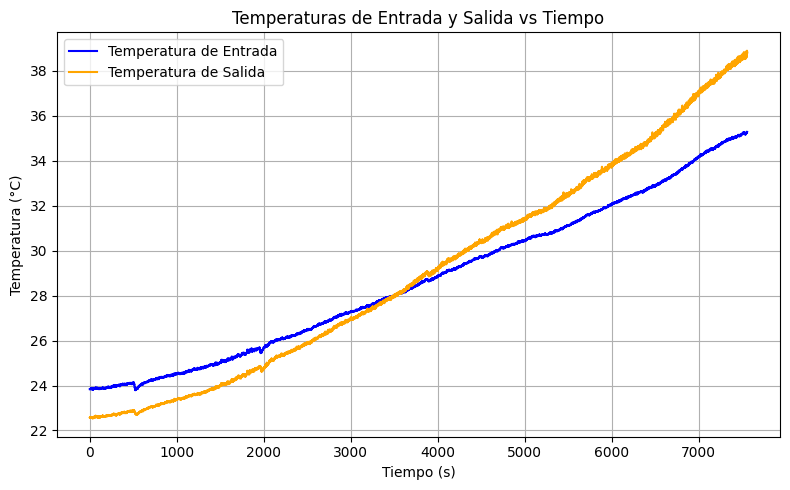

----------------------------------------------------------------------


/tmp/ipykernel_818/3838735061.py:52: RuntimeWarning: invalid value encountered in scalar divide
  c=aux/q
/tmp/ipykernel_818/3838735061.py:52: RuntimeWarning: divide by zero encountered in scalar divide
  c=aux/q


----------------------------------------------------------------------


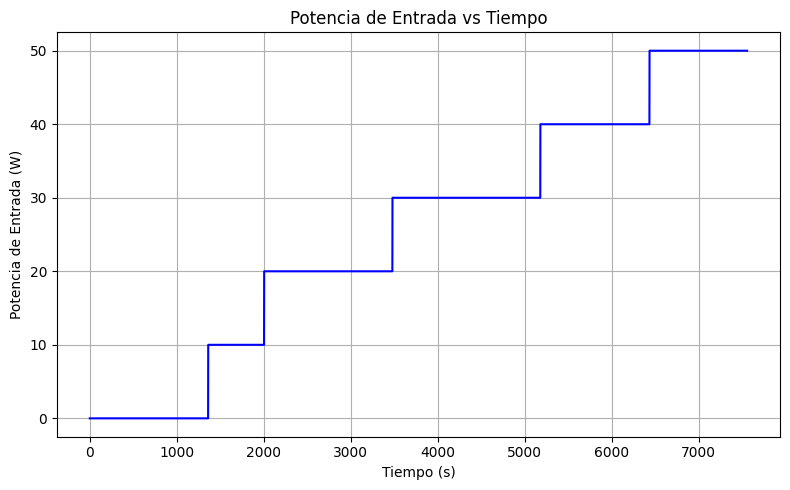

----------------------------------------------------------------------


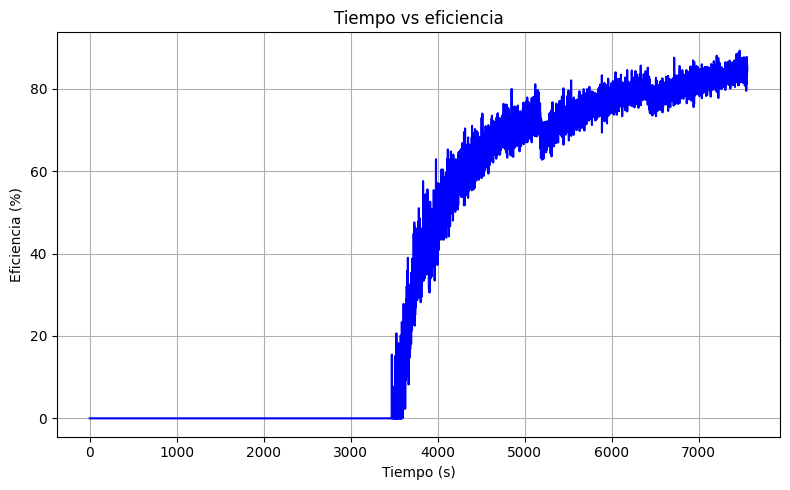

----------------------------------------------------------------------


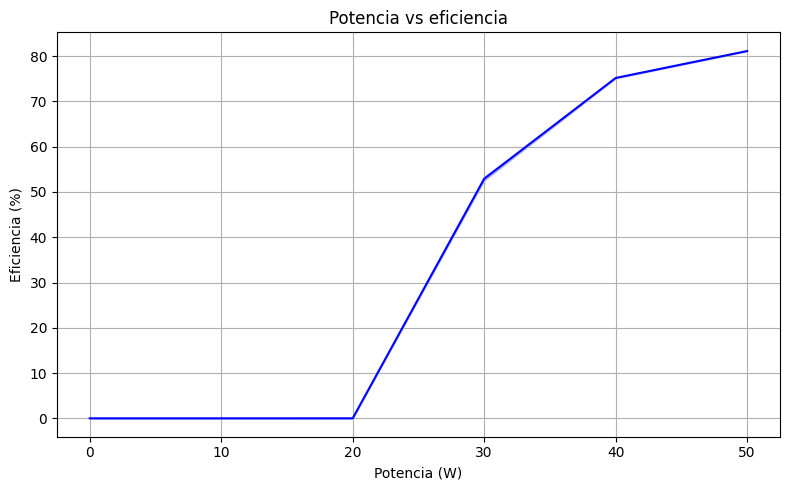

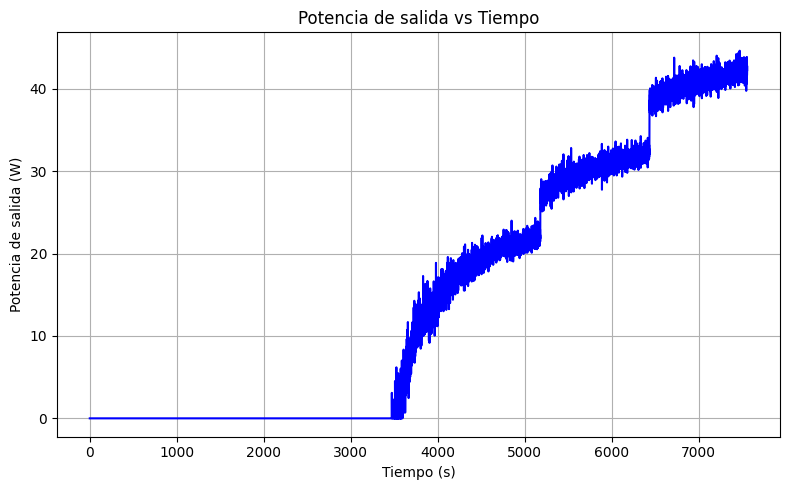

----------------------------------------------------------------------
       Temperatura de entrada  Temperatura de salida  Potencia Entrada  \
0                       23.84                  22.57               0.0   
1                       23.84                  22.56               0.0   
2                       23.84                  22.56               0.0   
3                       23.84                  22.56               0.0   
4                       23.84                  22.56               0.0   
...                       ...                    ...               ...   
36588                   35.28                  38.77              50.0   
36589                   35.28                  38.82              50.0   
36590                   35.28                  38.82              50.0   
36591                     NaN                    NaN              50.0   
36592                     NaN                    NaN              50.0   

       Eficiencia  Potencia de salida  R

In [ ]:
# Lectura de la base de datos
ruta = "/content/prueba_25_08_3_16.csv"
BaseDatos = ReadCSV(ruta)

x = BaseDatos["Tiempo (s)"]

# Asignar nombres claros a las temperaturas de entrada y salida
BaseDatos["Temperatura de entrada"] = BaseDatos["Canal 1 (°C)"]
BaseDatos["Temperatura de salida"] = BaseDatos["Canal 2 (°C)"]

tempEntrada = BaseDatos["Temperatura de entrada"]
tempSalida = BaseDatos["Temperatura de salida"]

# Graficar ambas temperaturas juntas para comparar su comportamiento
PlotearDosLineas(
    x,
    tempEntrada,
    tempSalida,
    "Temperatura de Entrada",
    "Temperatura de Salida",
    "Temperaturas de Entrada y Salida vs Tiempo",
    "Tiempo (s)",
    "Temperatura (°C)",
)
print("----------------------------------------------------------------------")

# Cálculo de la Potencia Recuperada
flujoMasico = 18.5
cp = 4.184

BaseDatos["Potencia recuperada"] = PotenciaRecuperada(
    flujoMasico, cp, tempEntrada, tempSalida
)
Qe = BaseDatos["Potencia recuperada"]
#Plotear(x, Qe, "Potencia Recuperada vs Tiempo", "Tiempo (s)", "Potencia Recuperada (W)")
print("----------------------------------------------------------------------")

# Cálculo de la Potencia de Entrada (Uso de Canal 5 y Canal 6)
BaseDatos["Potencia Entrada"] = PotenciaEntrada(
    BaseDatos["Canal 5 (°C)"], BaseDatos["Canal 6 (°C)"]
)
Qin = BaseDatos["Potencia Entrada"]
Plotear(x, Qin, "Potencia de Entrada vs Tiempo", "Tiempo (s)", "Potencia de Entrada (W)")
print("----------------------------------------------------------------------")

# Cálculo de la Eficiencia
BaseDatos["Eficiencia"] = Eficiencia(Qin, Qe)
eficiencia = BaseDatos["Eficiencia"]
Plotear(x, eficiencia, "Tiempo vs eficiencia", "Tiempo (s)", "Eficiencia (%)")
print("----------------------------------------------------------------------")

Plotear(Qin, eficiencia, "Potencia vs eficiencia", "Potencia (W)", "Eficiencia (%)")

#Potencia de salida

potenciaSalida=PotenciaRealSalida(eficiencia,Qin)
BaseDatos["Potencia de salida"]=potenciaSalida
Plotear(x, potenciaSalida, "Potencia de salida vs Tiempo", "Tiempo (s)", "Potencia de salida (W)")
print("----------------------------------------------------------------------")



# Cálculo de la Resistencia Térmica
tempCondProm = (BaseDatos["Canal 3 (°C)"] + BaseDatos["Canal 4 (°C)"]) / 2
tempEvapProm = (BaseDatos["Canal 5 (°C)"] + BaseDatos["Canal 6 (°C)"]) / 2
BaseDatos["Resistencia_Termica (°C/W)"] = ResistenciaTermica(
    tempEvapProm, tempCondProm, Qe
)

# Mostrar únicamente las columnas seleccionadas en el print final
columnas_deseadas = [
    "Temperatura de entrada",
    "Temperatura de salida",
    "Potencia Entrada",
    "Eficiencia",
    "Potencia de salida",
    "Resistencia_Termica (°C/W)"
]

print(BaseDatos[columnas_deseadas])
B2=BaseDatos[columnas_deseadas]

Offset detectado entre sensores a 0 W: -1.273 °C


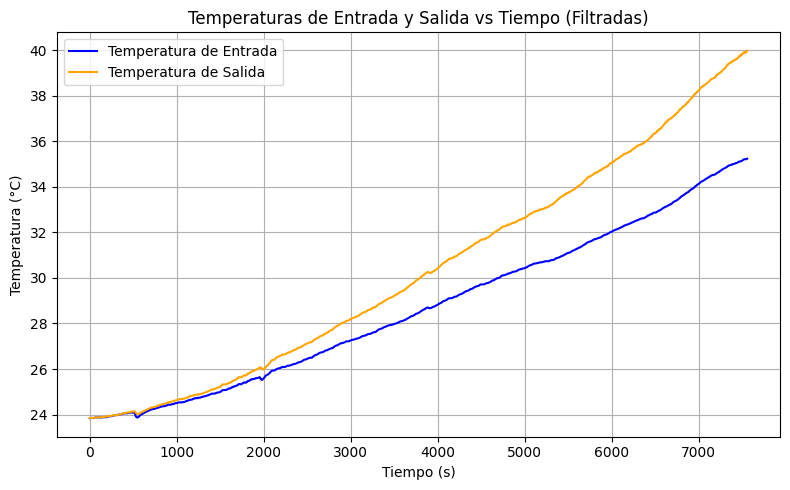

----------------------------------------------------------------------
----------------------------------------------------------------------
----------------------------------------------------------------------


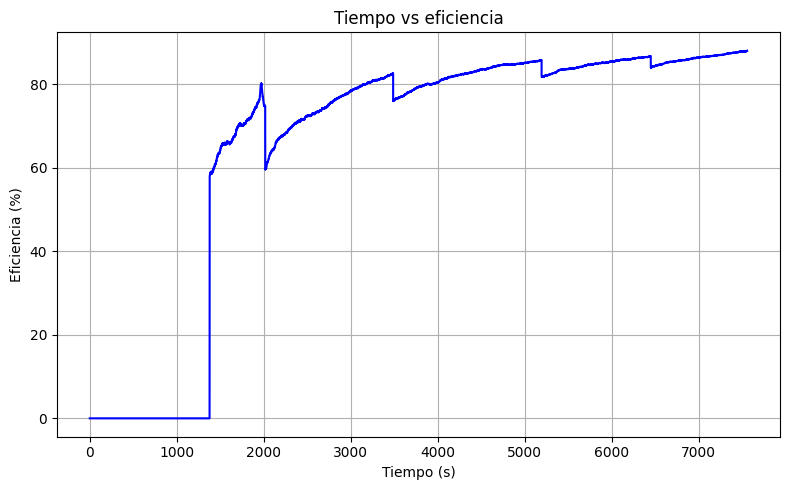

----------------------------------------------------------------------


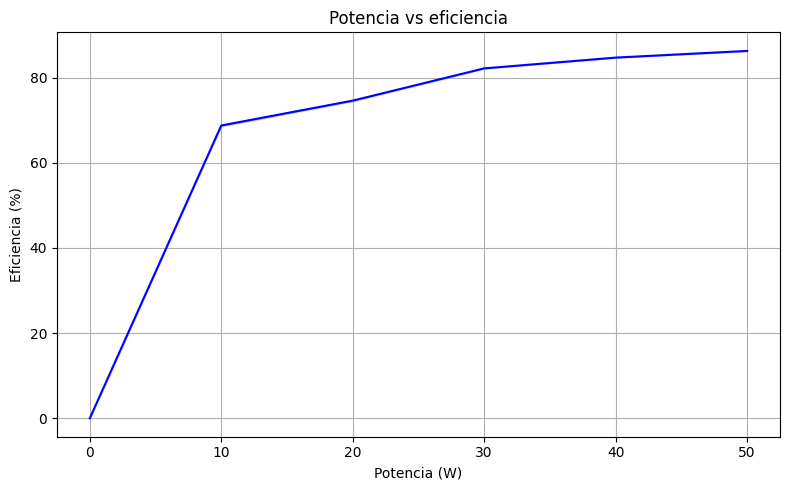

----------------------------------------------------------------------


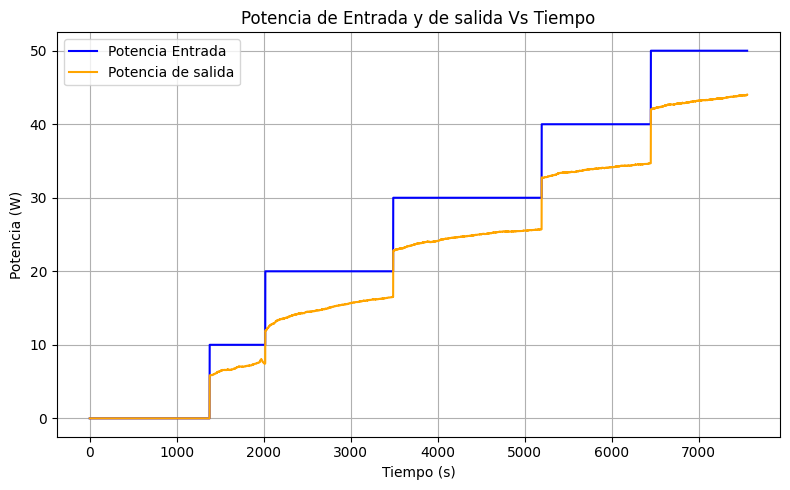

       Temperatura de entrada  Temperatura de salida  Potencia Entrada  \
0                   23.840000              23.843245               0.0   
1                   23.840000              23.838366               0.0   
2                   23.840000              23.836687               0.0   
3                   23.840000              23.835836               0.0   
4                   23.840000              23.835323               0.0   
...                       ...                    ...               ...   
36588               35.230634              39.967996              50.0   
36589               35.231327              39.969754              50.0   
36590               35.232011              39.971488              50.0   
36591                     NaN                    NaN              50.0   
36592                     NaN                    NaN              50.0   

       Eficiencia  Potencia de salida  Temperatura evaporador  
0        0.000000            0.000000          

In [ ]:
ruta = "/content/prueba_25_08_3_16.csv"
BaseDatos = ReadCSV(ruta)

x = BaseDatos["Tiempo (s)"]

# --- APLICAR FILTRO DE KALMAN A LOS CANALES DE TEMPERATURA ---
BaseDatos["Canal 1_filt"] = FiltroKalman1D(BaseDatos["Canal 1 (°C)"])
BaseDatos["Canal 2_filt"] = FiltroKalman1D(BaseDatos["Canal 2 (°C)"])
BaseDatos["Canal 3_filt"] = FiltroKalman1D(BaseDatos["Canal 3 (°C)"])
BaseDatos["Canal 4_filt"] = FiltroKalman1D(BaseDatos["Canal 4 (°C)"])
BaseDatos["Canal 5_filt"] = FiltroKalman1D(BaseDatos["Canal 5 (°C)"])
BaseDatos["Canal 6_filt"] = FiltroKalman1D(BaseDatos["Canal 6 (°C)"])

# --- 3. CORRECCIÓN DE DESFASE INICIAL (CALIBRACIÓN DE SENSORES) ---
n_puntos_reposo = 50
offset_inicial = (
    BaseDatos["Canal 2_filt"].iloc[:n_puntos_reposo]
    - BaseDatos["Canal 1_filt"].iloc[:n_puntos_reposo]
).mean()
print(f"Offset detectado entre sensores a 0 W: {offset_inicial:.3f} °C")

# Asignar nombres claros utilizando los canales filtrados
BaseDatos["Temperatura de entrada"] = BaseDatos["Canal 1_filt"]
BaseDatos["Temperatura de salida"] = BaseDatos["Canal 2_filt"] - offset_inicial

BaseDatos["Temperatura evaporador"] = (BaseDatos["Canal 5_filt"]+BaseDatos["Canal 6_filt"])/2

tempEntrada = BaseDatos["Temperatura de entrada"]
tempSalida = BaseDatos["Temperatura de salida"]

# Graficar ambas temperaturas juntas para comparar su comportamiento
PlotearDosLineas(
    x,
    tempEntrada,
    tempSalida,
    "Temperatura de Entrada",
    "Temperatura de Salida",
    "Temperaturas de Entrada y Salida vs Tiempo (Filtradas)",
    "Tiempo (s)",
    "Temperatura (°C)",
)
print("----------------------------------------------------------------------")

# Cálculo de la Potencia Recuperada
flujoMasico = 18.5
cp = 4.184

BaseDatos["Potencia recuperada"] = PotenciaRecuperada(
    flujoMasico, cp, tempEntrada, tempSalida
)
Qe = BaseDatos["Potencia recuperada"]
print("----------------------------------------------------------------------")

# Cálculo de la Potencia de Entrada (Uso de Canal 5 y Canal 6 filtrados)
BaseDatos["Potencia Entrada"] = PotenciaEntrada(
    BaseDatos["Canal 5_filt"], BaseDatos["Canal 6_filt"]
)
Qin = BaseDatos["Potencia Entrada"]
#Plotear(x, Qin, "Potencia de Entrada vs Tiempo", "Tiempo (s)", "Potencia de Entrada (W)")
print("----------------------------------------------------------------------")

# Cálculo de la Eficiencia
BaseDatos["Eficiencia"] = Eficiencia(Qin, Qe)
eficiencia = BaseDatos["Eficiencia"]
Plotear(x, eficiencia, "Tiempo vs eficiencia", "Tiempo (s)", "Eficiencia (%)")
print("----------------------------------------------------------------------")

Plotear(Qin, eficiencia, "Potencia vs eficiencia", "Potencia (W)", "Eficiencia (%)")

# Potencia de salida
potenciaSalida = PotenciaRealSalida(eficiencia, Qin)
BaseDatos["Potencia de salida"] = potenciaSalida
#Plotear(x, potenciaSalida, "Potencia de salida vs Tiempo", "Tiempo (s)", "Potencia de salida (W)")
print("----------------------------------------------------------------------")

PlotearDosLineas(
    x,
    Qin,
    potenciaSalida,
    "Potencia Entrada",
    "Potencia de salida",
    "Potencia de Entrada y de salida Vs Tiempo",
    "Tiempo (s)",
    "Potencia (W)",
)

# Cálculo de la Resistencia Térmica usando canales filtrados
tempCondProm = (BaseDatos["Canal 3_filt"] + BaseDatos["Canal 4_filt"]) / 2
tempEvapProm = (BaseDatos["Canal 5_filt"] + BaseDatos["Canal 6_filt"]) / 2
BaseDatos["Resistencia_Termica (°C/W)"] = ResistenciaTermica(
    tempEvapProm, tempCondProm, Qe
)

# Mostrar únicamente las columnas seleccionadas en el print final
columnas_deseadas = [
    "Temperatura de entrada",
    "Temperatura de salida",
    "Potencia Entrada",
    "Eficiencia",
    "Potencia de salida",
    "Temperatura evaporador"
]

print(BaseDatos[columnas_deseadas])
B2F = BaseDatos[columnas_deseadas]



---



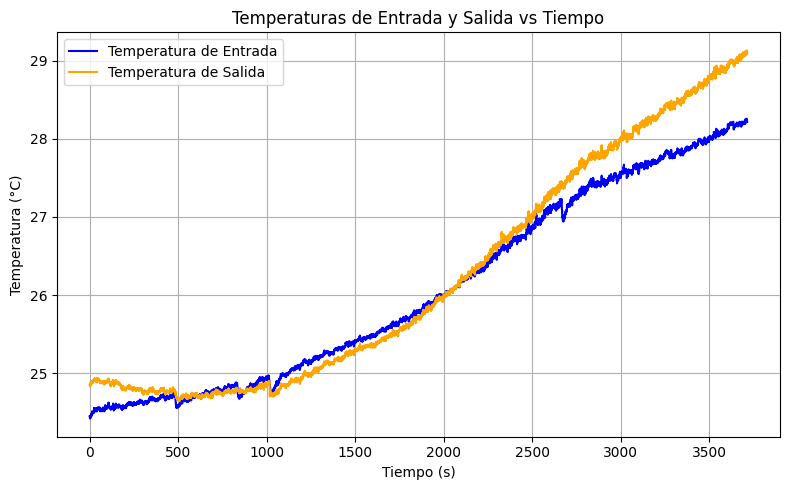

----------------------------------------------------------------------
----------------------------------------------------------------------


/tmp/ipykernel_818/3838735061.py:52: RuntimeWarning: divide by zero encountered in scalar divide
  c=aux/q
/tmp/ipykernel_818/3838735061.py:52: RuntimeWarning: invalid value encountered in scalar divide
  c=aux/q


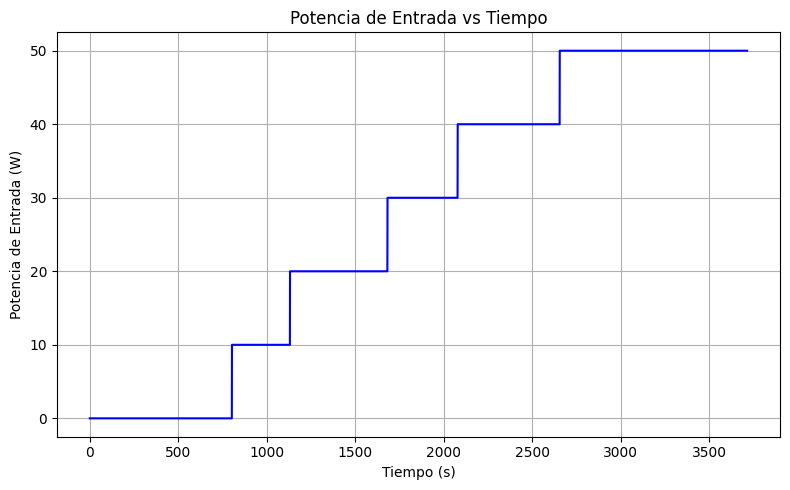

----------------------------------------------------------------------


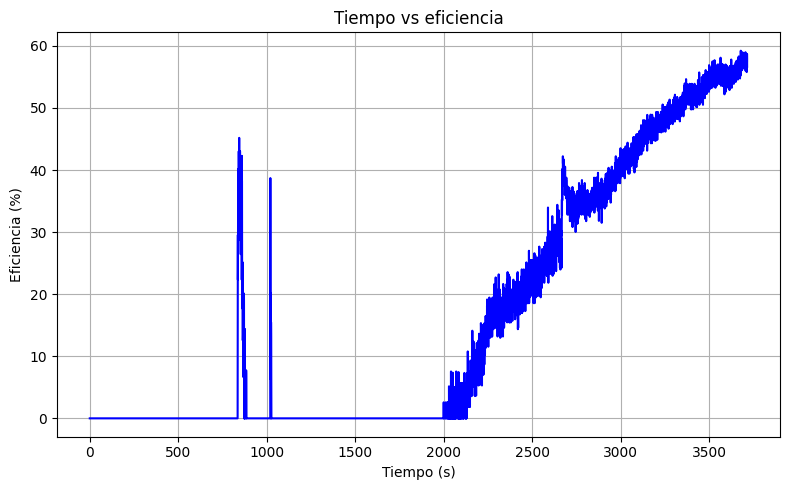

----------------------------------------------------------------------


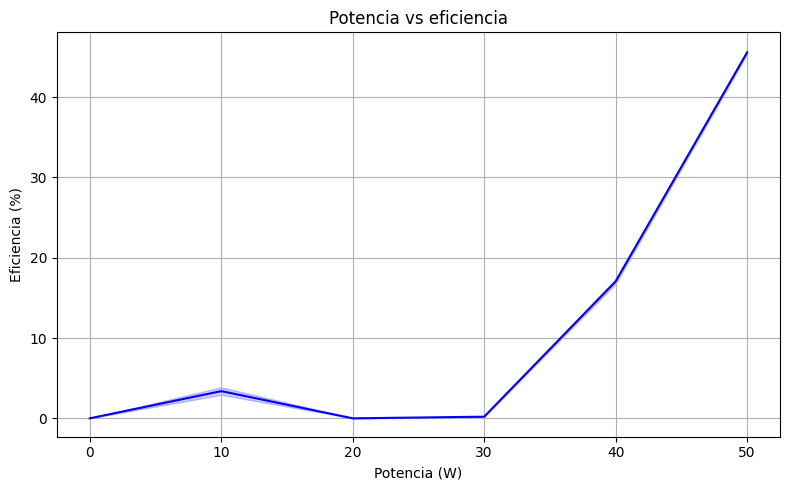

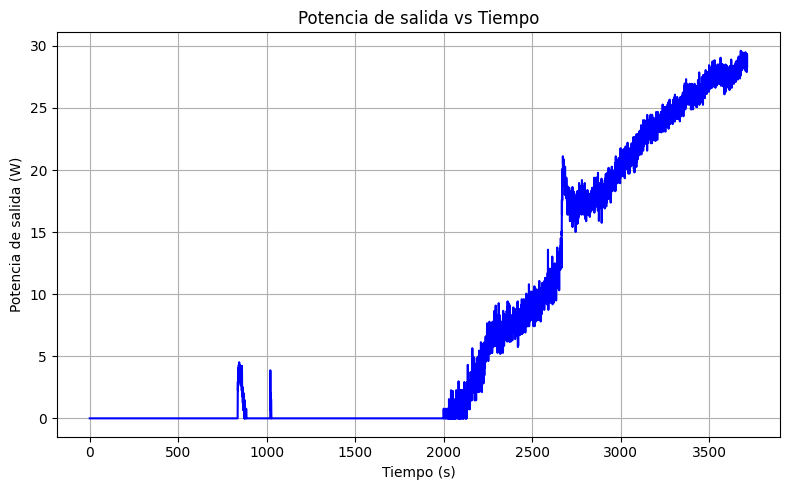

----------------------------------------------------------------------
       Temperatura de entrada  Temperatura de salida  Potencia recuperada  \
0                       24.45                  24.85             30.96160   
1                       24.45                  24.86             31.73564   
2                       24.43                  24.86             33.28372   
3                       24.43                  24.86             33.28372   
4                       24.43                  24.84             31.73564   
...                       ...                    ...                  ...   
17830                   28.22                  29.11             68.88956   
17831                   28.22                  29.11             68.88956   
17832                   28.22                  29.09             67.34148   
17833                     NaN                    NaN                  NaN   
17834                     NaN                    NaN                  NaN   

    

In [ ]:
# Lectura de la base de datos
ruta = "/content/Prueba_24_08.csv"
BaseDatos = ReadCSV(ruta)

x = BaseDatos["Tiempo (s)"]

# --- CORRECCIÓN DE DESFASE INICIAL (CALIBRACIÓN DE SENSORES) ---
n_puntos_reposo = 50
offset_inicial = (
    BaseDatos["Canal 2 (°C)"] - BaseDatos["Canal 1 (°C)"]
).mean()

offset_inicial=0.5
# Asignar nombres claros y aplicar el offset de calibración directamente a la salida
BaseDatos["Temperatura de entrada"] = BaseDatos["Canal 1 (°C)"]- offset_inicial

BaseDatos["Temperatura de salida"] = BaseDatos["Canal 2 (°C)"] - 0.3
tempEntrada = BaseDatos["Temperatura de entrada"]
tempSalida = BaseDatos["Temperatura de salida"]

# Graficar ambas temperaturas juntas para comparar su comportamiento
PlotearDosLineas(
    x,
    tempEntrada,
    tempSalida,
    "Temperatura de Entrada",
    "Temperatura de Salida",
    "Temperaturas de Entrada y Salida vs Tiempo",
    "Tiempo (s)",
    "Temperatura (°C)",
)
print("----------------------------------------------------------------------")

# Cálculo de la Potencia Recuperada
flujoMasico = 18.5
cp = 4.184

BaseDatos["Potencia recuperada"] = PotenciaRecuperada(
    flujoMasico, cp, tempEntrada, tempSalida
)
Qe = BaseDatos["Potencia recuperada"]
#Plotear(x, Qe, "Potencia Recuperada vs Tiempo", "Tiempo (s)", "Potencia Recuperada (W)")
print("----------------------------------------------------------------------")

# Cálculo de la Potencia de Entrada (Uso de Canal 5 y Canal 6)
BaseDatos["Potencia Entrada"] = PotenciaEntrada(
    BaseDatos["Canal 5 (°C)"], BaseDatos["Canal 6 (°C)"]
)
Qin = BaseDatos["Potencia Entrada"]
Plotear(x, Qin, "Potencia de Entrada vs Tiempo", "Tiempo (s)", "Potencia de Entrada (W)")
print("----------------------------------------------------------------------")

# Cálculo de la Eficiencia
BaseDatos["Eficiencia"] = Eficiencia(Qin, Qe)
eficiencia = BaseDatos["Eficiencia"]
Plotear(x, eficiencia, "Tiempo vs eficiencia", "Tiempo (s)", "Eficiencia (%)")
print("----------------------------------------------------------------------")

Plotear(Qin, eficiencia, "Potencia vs eficiencia", "Potencia (W)", "Eficiencia (%)")

#Potencia de salida

potenciaSalida=PotenciaRealSalida(eficiencia,Qin)
BaseDatos["Potencia de salida"]=potenciaSalida
Plotear(x, potenciaSalida, "Potencia de salida vs Tiempo", "Tiempo (s)", "Potencia de salida (W)")
print("----------------------------------------------------------------------")



# Cálculo de la Resistencia Térmica
tempCondProm = (BaseDatos["Canal 3 (°C)"] + BaseDatos["Canal 4 (°C)"]) / 2
tempEvapProm = (BaseDatos["Canal 5 (°C)"] + BaseDatos["Canal 6 (°C)"]) / 2
BaseDatos["Resistencia_Termica (°C/W)"] = ResistenciaTermica(
    tempEvapProm, tempCondProm, Qe
)

# Mostrar únicamente las columnas seleccionadas en el print final
columnas_deseadas = [
    "Temperatura de entrada",
    "Temperatura de salida",
    "Potencia recuperada",
    "Potencia Entrada",
    "Eficiencia",
    "Potencia de salida"
]

print(BaseDatos[columnas_deseadas])
B3=BaseDatos[columnas_deseadas]

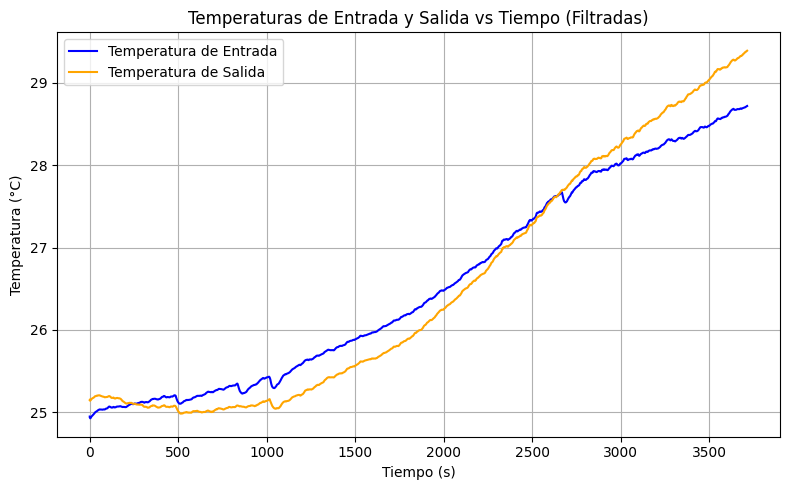

----------------------------------------------------------------------
----------------------------------------------------------------------
----------------------------------------------------------------------
----------------------------------------------------------------------
----------------------------------------------------------------------


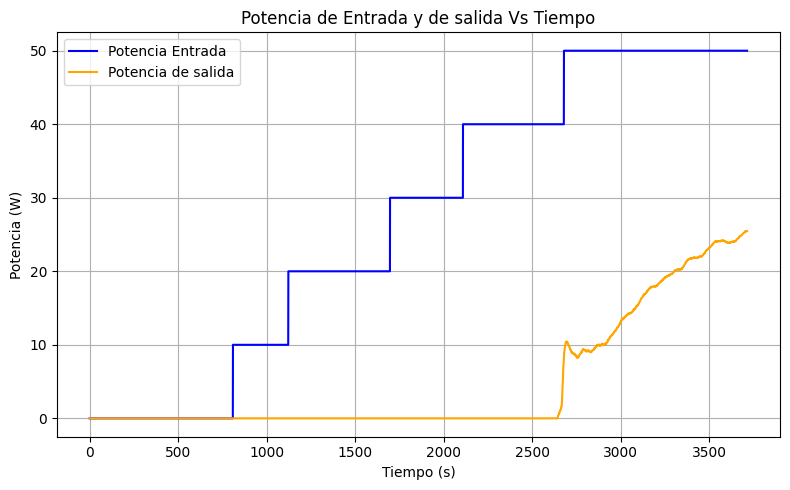

       Temperatura de entrada  Temperatura de salida  Potencia Entrada  \
0                   24.950000              25.150000               0.0   
1                   24.950000              25.154879               0.0   
2                   24.943440              25.156558               0.0   
3                   24.940119              25.157409               0.0   
4                   24.938113              25.153957               0.0   
...                       ...                    ...               ...   
17830               28.717468              29.387280              50.0   
17831               28.717504              29.387599              50.0   
17832               28.717539              29.387633              50.0   
17833                     NaN                    NaN              50.0   
17834                     NaN                    NaN              50.0   

       Eficiencia  Potencia de salida  Temperatura evaporador  
0        0.000000            0.000000          

In [ ]:
ruta = "/content/Prueba_24_08.csv"
BaseDatos = ReadCSV(ruta)

x = BaseDatos["Tiempo (s)"]

# --- APLICAR FILTRO DE KALMAN A LOS CANALES DE TEMPERATURA ---
BaseDatos["Canal 1_filt"] = FiltroKalman1D(BaseDatos["Canal 1 (°C)"])
BaseDatos["Canal 2_filt"] = FiltroKalman1D(BaseDatos["Canal 2 (°C)"])
BaseDatos["Canal 3_filt"] = FiltroKalman1D(BaseDatos["Canal 3 (°C)"])
BaseDatos["Canal 4_filt"] = FiltroKalman1D(BaseDatos["Canal 4 (°C)"])
BaseDatos["Canal 5_filt"] = FiltroKalman1D(BaseDatos["Canal 5 (°C)"])
BaseDatos["Canal 6_filt"] = FiltroKalman1D(BaseDatos["Canal 6 (°C)"])

# Asignar nombres claros utilizando los canales filtrados
BaseDatos["Temperatura de entrada"] = BaseDatos["Canal 1_filt"]
BaseDatos["Temperatura de salida"] = BaseDatos["Canal 2_filt"]

tempEntrada = BaseDatos["Temperatura de entrada"]
tempSalida = BaseDatos["Temperatura de salida"]

BaseDatos["Temperatura evaporador"] = (BaseDatos["Canal 5_filt"]+BaseDatos["Canal 6_filt"])/2

# Graficar ambas temperaturas juntas para comparar su comportamiento
PlotearDosLineas(
    x,
    tempEntrada,
    tempSalida,
    "Temperatura de Entrada",
    "Temperatura de Salida",
    "Temperaturas de Entrada y Salida vs Tiempo (Filtradas)",
    "Tiempo (s)",
    "Temperatura (°C)",
)
print("----------------------------------------------------------------------")

# Cálculo de la Potencia Recuperada
flujoMasico = 18.5
cp = 4.184

BaseDatos["Potencia recuperada"] = PotenciaRecuperada(
    flujoMasico, cp, tempEntrada, tempSalida
)
Qe = BaseDatos["Potencia recuperada"]
print("----------------------------------------------------------------------")

# Cálculo de la Potencia de Entrada (Uso de Canal 5 y Canal 6 filtrados)
BaseDatos["Potencia Entrada"] = PotenciaEntrada(
    BaseDatos["Canal 5_filt"], BaseDatos["Canal 6_filt"]
)
Qin = BaseDatos["Potencia Entrada"]
#Plotear(x, Qin, "Potencia de Entrada vs Tiempo", "Tiempo (s)", "Potencia de Entrada (W)")
print("----------------------------------------------------------------------")

# Cálculo de la Eficiencia
BaseDatos["Eficiencia"] = Eficiencia(Qin, Qe)
eficiencia = BaseDatos["Eficiencia"]
#Plotear(x, eficiencia, "Tiempo vs eficiencia", "Tiempo (s)", "Eficiencia (%)")
print("----------------------------------------------------------------------")

#Plotear(Qin, eficiencia, "Potencia vs eficiencia", "Potencia (W)", "Eficiencia (%)")

# Potencia de salida
potenciaSalida = PotenciaRealSalida(eficiencia, Qin)
BaseDatos["Potencia de salida"] = potenciaSalida
#Plotear(x, potenciaSalida, "Potencia de salida vs Tiempo", "Tiempo (s)", "Potencia de salida (W)")
print("----------------------------------------------------------------------")

PlotearDosLineas(
    x,
    Qin,
    potenciaSalida,
    "Potencia Entrada",
    "Potencia de salida",
    "Potencia de Entrada y de salida Vs Tiempo",
    "Tiempo (s)",
    "Potencia (W)",
)

# Cálculo de la Resistencia Térmica usando canales filtrados
tempCondProm = (BaseDatos["Canal 3_filt"] + BaseDatos["Canal 4_filt"]) / 2
tempEvapProm = (BaseDatos["Canal 5_filt"] + BaseDatos["Canal 6_filt"]) / 2
BaseDatos["Resistencia_Termica (°C/W)"] = ResistenciaTermica(
    tempEvapProm, tempCondProm, Qe
)

# Mostrar únicamente las columnas seleccionadas en el print final
columnas_deseadas = [
    "Temperatura de entrada",
    "Temperatura de salida",
    "Potencia Entrada",
    "Eficiencia",
    "Potencia de salida",
    "Temperatura evaporador"
]

print(BaseDatos[columnas_deseadas])
B3F = BaseDatos[columnas_deseadas]

   Tiempo (s)  canal_1  canal_2  canal_3  canal_4
0         0.0    26.25    25.25    24.75    28.50
1         2.0    26.50    25.50    24.50    28.50
2         4.0    26.00    25.25    25.25    28.50
3         6.0    26.25    25.25    25.25    28.75
4         8.0    25.75    24.75    25.25    28.50
Offset detectado entre sensores a 0 W: -0.898 °C


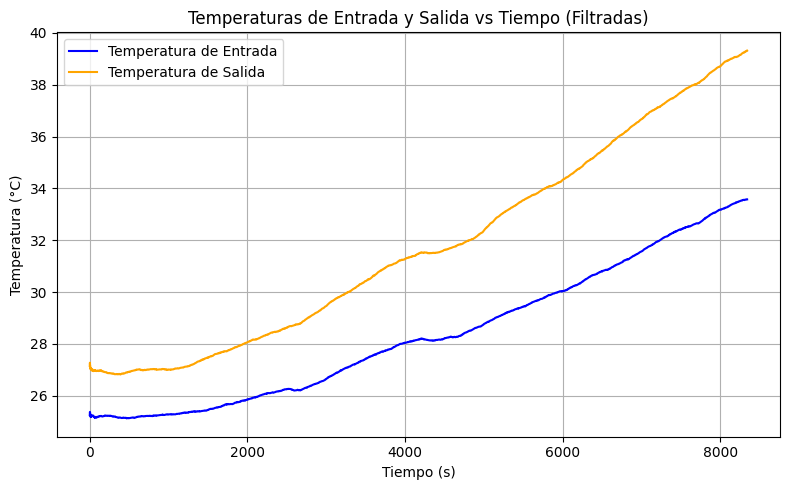

----------------------------------------------------------------------
----------------------------------------------------------------------
----------------------------------------------------------------------


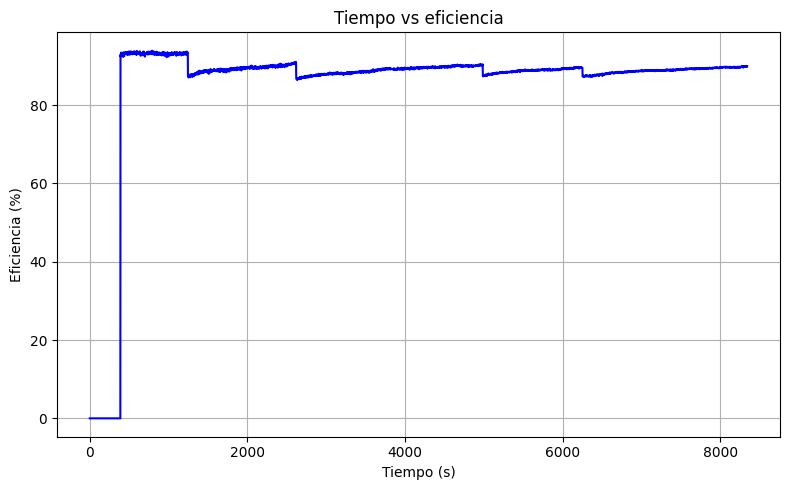

----------------------------------------------------------------------
----------------------------------------------------------------------


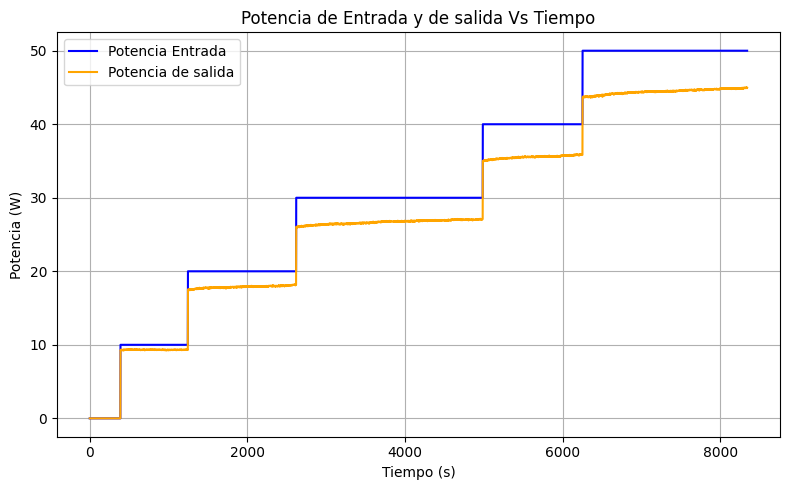

      Tiempo (s)  Temperatura de entrada  Temperatura de salida  \
0            0.0               25.250000              27.148147   
1            2.0               25.371964              27.270112   
2            4.0               25.331962              27.148114   
3            6.0               25.311710              27.148122   
4            8.0               25.200344              27.048995   
...          ...                     ...                    ...   
4167      8334.0               33.572929              39.306608   
4168      8336.0               33.575416              39.311404   
4169      8338.0               33.574357              39.316133   
4170      8340.0               33.573313              39.310263   
4171      8342.0               33.575794              39.315008   

      Temperatura evaporador  Potencia Entrada  Eficiencia  Potencia de salida  
0                  26.625000               0.0    0.000000            0.000000  
1                  26.564018     

In [ ]:
# --- 1. LECTURA DE LA BASE DE DATOS ---
ruta = "/content/dataultima_ok_602_316.csv"
BaseDatos = pd.read_csv(ruta, sep=',')

print(BaseDatos.head())

# Aseguramos que la columna de tiempo esté clara desde el inicio
if "tiempo" in BaseDatos.columns:
    x = BaseDatos["tiempo"]
elif "Tiempo (s)" in BaseDatos.columns:
    x = BaseDatos["Tiempo (s)"]
else:
    x = BaseDatos.iloc[:, 0] # Por seguridad toma la primera columna

# --- 2. APLICACIÓN DEL FILTRO DE KALMAN A LOS CANALES RUIDOSOS ---
BaseDatos["canal_1_filt"] = FiltroKalman1D(BaseDatos["canal_1"])
BaseDatos["canal_2_filt"] = FiltroKalman1D(BaseDatos["canal_2"])
BaseDatos["canal_3_filt"] = FiltroKalman1D(BaseDatos["canal_3"])
BaseDatos["canal_4_filt"] = FiltroKalman1D(BaseDatos["canal_4"])

# --- 3. CORRECCIÓN DE DESFASE INICIAL (CALIBRACIÓN DE SENSORES) ---
n_puntos_reposo = 50
offset_inicial = (
    BaseDatos["canal_2_filt"].iloc[:n_puntos_reposo]
    - BaseDatos["canal_1_filt"].iloc[:n_puntos_reposo]
).mean()
print(f"Offset detectado entre sensores a 0 W: {offset_inicial:.3f} °C")

# Asignar nombres claros usando los datos ya filtrados
BaseDatos["Temperatura de entrada"] = BaseDatos["canal_2_filt"]
BaseDatos["Temperatura de salida"] = BaseDatos["canal_1_filt"] - offset_inicial
tempEntrada = BaseDatos["Temperatura de entrada"]
tempSalida = BaseDatos["Temperatura de salida"]

# Temperatura evaporador (usando minúsculas como se definieron en el filtro)
BaseDatos["Temperatura evaporador"] = (BaseDatos["canal_3_filt"] + BaseDatos["canal_4_filt"]) / 2

# Graficar ambas temperaturas juntas
PlotearDosLineas(
    x,
    tempEntrada,
    tempSalida,
    "Temperatura de Entrada",
    "Temperatura de Salida",
    "Temperaturas de Entrada y Salida vs Tiempo (Filtradas)",
    "Tiempo (s)",
    "Temperatura (°C)",
)
print("----------------------------------------------------------------------")

# --- 4. CÁLCULO DE POTENCIAS Y EFICIENCIA ---
flujoMasico = 18.5
cp = 4.184

BaseDatos["Potencia recuperada"] = PotenciaRecuperada(
    flujoMasico, cp, tempEntrada, tempSalida
)
Qe = BaseDatos["Potencia recuperada"]
print("----------------------------------------------------------------------")

# Usando los canales 4 y 3 filtrados para la Potencia de Entrada
BaseDatos["Potencia Entrada"] = PotenciaEntrada(BaseDatos["canal_4_filt"], BaseDatos["canal_3_filt"])
Qin = BaseDatos["Potencia Entrada"]
print("----------------------------------------------------------------------")

BaseDatos["Eficiencia"] = Eficiencia(Qin, Qe)
eficiencia = BaseDatos["Eficiencia"]
Plotear(x, eficiencia, "Tiempo vs eficiencia", "Tiempo (s)", "Eficiencia (%)")
print("----------------------------------------------------------------------")

# Potencia de salida
potenciaSalida = PotenciaRealSalida(eficiencia, Qin)
BaseDatos["Potencia de salida"] = potenciaSalida
print("----------------------------------------------------------------------")

PlotearDosLineas(
    x,
    Qin,
    potenciaSalida,
    "Potencia Entrada",
    "Potencia de salida",
    "Potencia de Entrada y de salida Vs Tiempo",
    "Tiempo (s)",
    "Potencia (W)",
)

# --- 5. EXPORTACIÓN DE RESULTADOS ---
# ¡IMPORTANTE! Incluimos la columna del tiempo de primera para que las gráficas la detecten bien
columnas_deseadas = [
    "tiempo", # O el nombre exacto con el que viene en este CSV específico
    "Temperatura de entrada",
    "Temperatura de salida",
    "Temperatura evaporador",
    "Potencia Entrada",
    "Eficiencia",
    "Potencia de salida"
]

# Por si tu columna se llama "Tiempo (s)" en este archivo en específico, la ajustamos dinámicamente si fuera necesario:
if "tiempo" not in BaseDatos.columns and "Tiempo (s)" in BaseDatos.columns:
    columnas_deseadas[0] = "Tiempo (s)"

print(BaseDatos[columnas_deseadas])
B4F = BaseDatos[columnas_deseadas]

   tiempo  canal_1  canal_2  canal_3  canal_4
0     0.0    25.25    25.00    20.75    30.25
1     2.0    25.50    25.25    20.75    30.25
2     4.0    25.25    24.75    21.00    29.75
3     6.0    24.50    25.00    21.00    30.25
4     8.0    25.50    25.00    21.00    30.00
Offset detectado entre sensores a 0 W: -0.086 °C


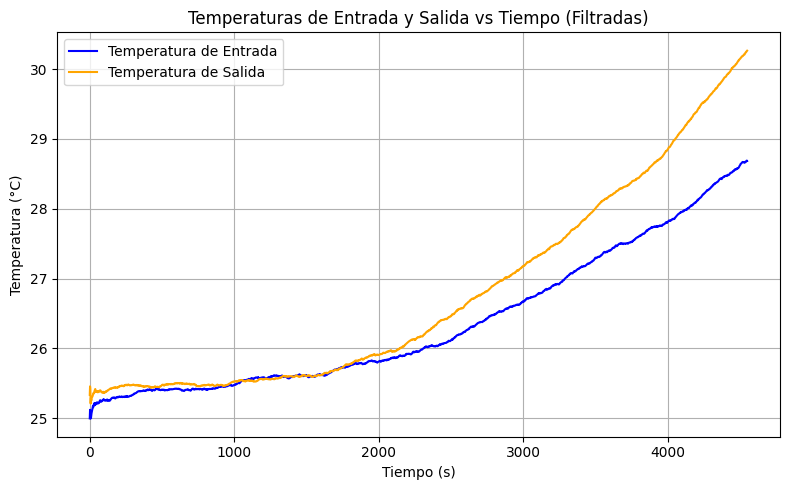

----------------------------------------------------------------------
----------------------------------------------------------------------
----------------------------------------------------------------------


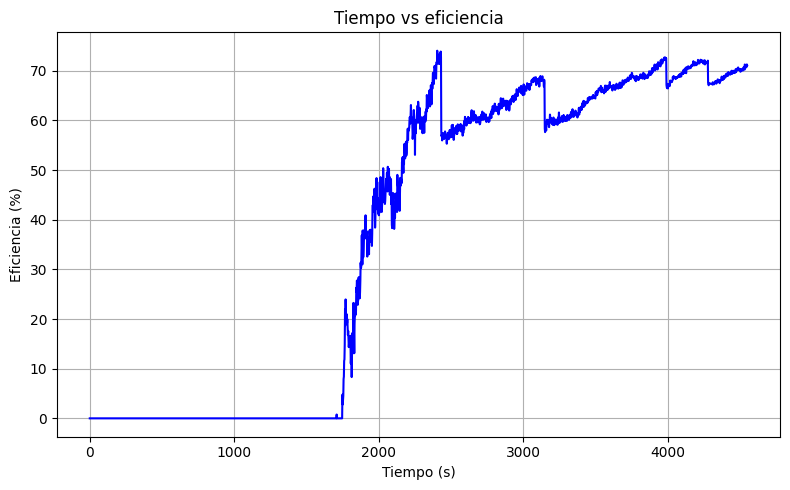

----------------------------------------------------------------------


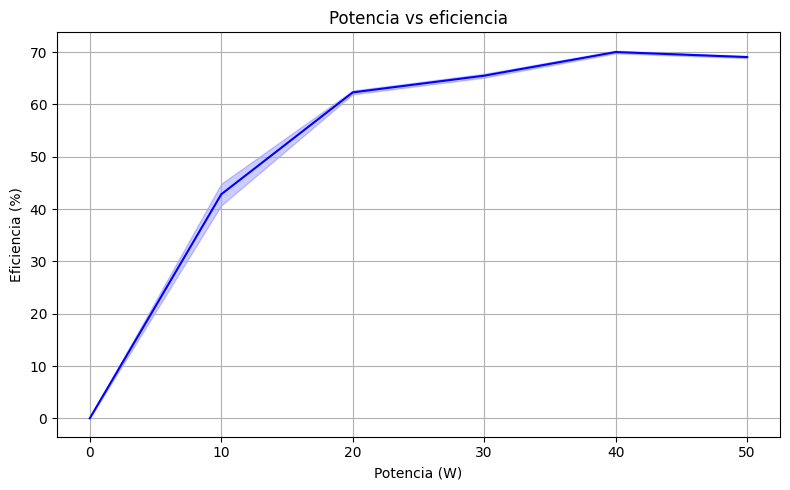

----------------------------------------------------------------------


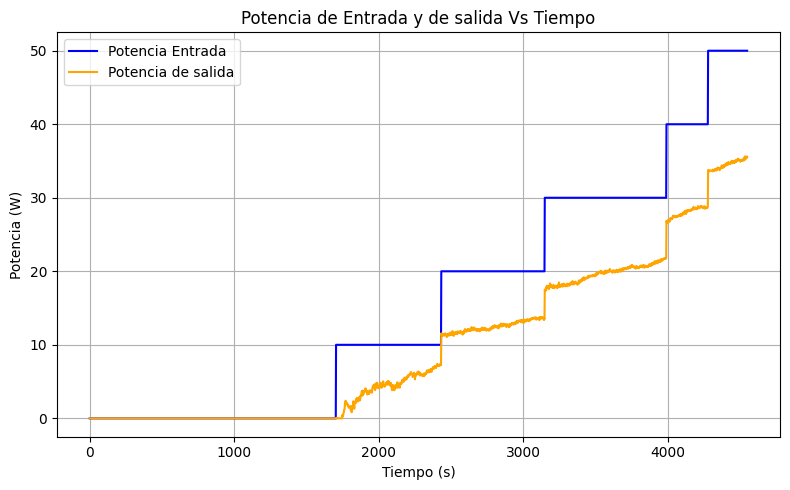

----------------------------------------------------------------------
      Temperatura de entrada  Temperatura de salida  Potencia Entrada  \
0                  25.000000              25.335897               0.0   
1                  25.121964              25.457861               0.0   
2                  24.999966              25.417859               0.0   
3                  24.999975              25.212288               0.0   
4                  24.999980              25.286361               0.0   
...                      ...                    ...               ...   
2243               28.676307              30.243539              50.0   
2244               28.680852              30.244836              50.0   
2245               28.688845              30.253136              50.0   
2246               28.682682              30.257809              50.0   
2247               28.683627              30.262416              50.0   

      Eficiencia  Potencia de salida  Temperatura ev

In [ ]:
# --- 1. LECTURA DE LA BASE DE DATOS ---
ruta = "/content/TermSinFluidoT.csv"
BaseDatos = pd.read_csv(ruta, sep=',')

print(BaseDatos.head())
x = BaseDatos["tiempo"]

# --- 2. APLICACIÓN DEL FILTRO DE KALMAN A LOS CANALES RUIDOSOS ---
BaseDatos["canal_1_filt"] = FiltroKalman1D(BaseDatos["canal_1"])
BaseDatos["canal_2_filt"] = FiltroKalman1D(BaseDatos["canal_2"])
BaseDatos["canal_3_filt"] = FiltroKalman1D(BaseDatos["canal_3"])
BaseDatos["canal_4_filt"] = FiltroKalman1D(BaseDatos["canal_4"])

# --- 3. CORRECCIÓN DE DESFASE INICIAL (CALIBRACIÓN DE SENSORES) ---
n_puntos_reposo = 50
offset_inicial = (
    BaseDatos["canal_2_filt"].iloc[:n_puntos_reposo]
    - BaseDatos["canal_1_filt"].iloc[:n_puntos_reposo]
).mean()
print(f"Offset detectado entre sensores a 0 W: {offset_inicial:.3f} °C")

# Asignar nombres claros usando los datos ya filtrados
BaseDatos["Temperatura de entrada"] = BaseDatos["canal_2_filt"]
BaseDatos["Temperatura de salida"] = BaseDatos["canal_1_filt"] - offset_inicial

tempEntrada = BaseDatos["Temperatura de entrada"]
tempSalida = BaseDatos["Temperatura de salida"]

BaseDatos["Temperatura evaporador"] = (BaseDatos["canal_3_filt"]+BaseDatos["canal_4_filt"])/2


# Graficar ambas temperaturas juntas
PlotearDosLineas(
    x,
    tempEntrada,
    tempSalida,
    "Temperatura de Entrada",
    "Temperatura de Salida",
    "Temperaturas de Entrada y Salida vs Tiempo (Filtradas)",
    "Tiempo (s)",
    "Temperatura (°C)",
)
print("----------------------------------------------------------------------")

# --- 4. CÁLCULO DE POTENCIAS Y EFICIENCIA ---
flujoMasico = 18.5
cp = 4.184

BaseDatos["Potencia recuperada"] = PotenciaRecuperada(
    flujoMasico, cp, tempEntrada, tempSalida
)
Qe = BaseDatos["Potencia recuperada"]
print("----------------------------------------------------------------------")

# Usando los canales 4 y 3 filtrados para la Potencia de Entrada
BaseDatos["Potencia Entrada"] = PotenciaEntrada(BaseDatos["canal_4_filt"], BaseDatos["canal_3_filt"])
Qin = BaseDatos["Potencia Entrada"]
#Plotear(x, Qin, "Potencia de Entrada vs Tiempo", "Tiempo (s)", "Potencia de Entrada (W)")
print("----------------------------------------------------------------------")

BaseDatos["Eficiencia"] = Eficiencia(Qin, Qe)
eficiencia = BaseDatos["Eficiencia"]
Plotear(x, eficiencia, "Tiempo vs eficiencia", "Tiempo (s)", "Eficiencia (%)")
print("----------------------------------------------------------------------")

Plotear(Qin, eficiencia, "Potencia vs eficiencia", "Potencia (W)", "Eficiencia (%)")

# Potencia de salida
potenciaSalida = PotenciaRealSalida(eficiencia, Qin)
BaseDatos["Potencia de salida"] = potenciaSalida
#Plotear(x, potenciaSalida, "Potencia de salida vs Tiempo", "Tiempo (s)", "Potencia de salida (W)")
print("----------------------------------------------------------------------")

PlotearDosLineas(
    x,
    Qin,
    potenciaSalida,
    "Potencia Entrada",
    "Potencia de salida",
    "Potencia de Entrada y de salida Vs Tiempo",
    "Tiempo (s)",
    "Potencia (W)",
)
print("----------------------------------------------------------------------")

# --- 5. EXPORTACIÓN DE RESULTADOS ---
columnas_deseadas = [
    "Temperatura de entrada",
    "Temperatura de salida",
    "Potencia Entrada",
    "Eficiencia",
    "Potencia de salida",
    "Temperatura evaporador"
]

print(BaseDatos[columnas_deseadas])
B5F = BaseDatos[columnas_deseadas]

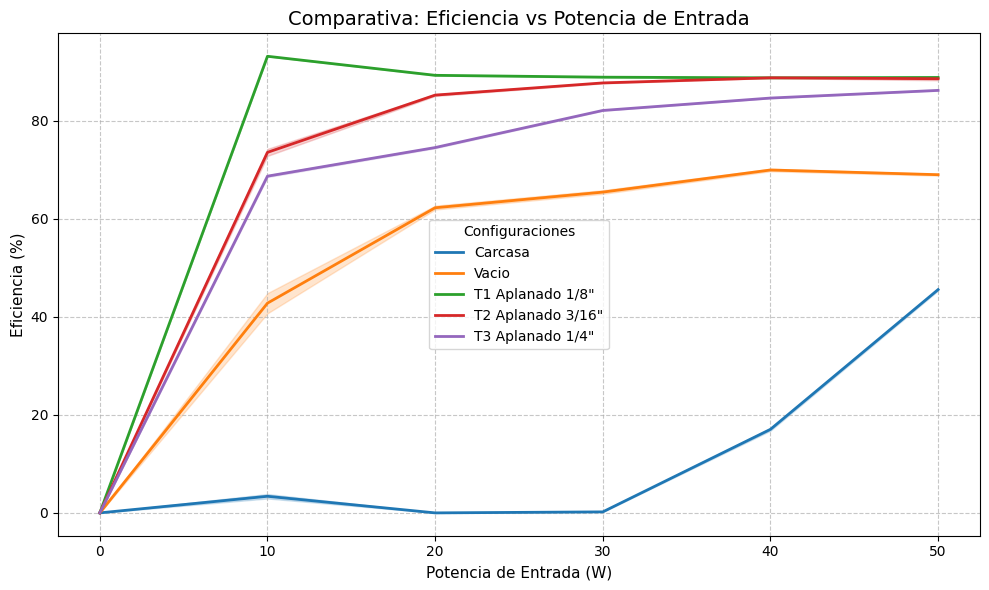

In [ ]:
BDS = [B3, B5F, B4F, B1F, B2F]
LG = ['Carcasa', 'Vacio', 'T1 Aplanado 1/8"', 'T2 Aplanado 3/16"', 'T3 Aplanado 1/4"']

plt.figure(figsize=(10, 6))

for i in range(len(BDS)):
    DataFrame = BDS[i]

    # Buscar potencia de entrada asegurando coincidencia
    col_qin = next((col for col in DataFrame.columns if 'potencia' in col.lower() and 'entrada' in col.lower()), 'Potencia Entrada')

    # Buscar eficiencia de forma flexible (mayúscula o minúscula)
    col_efi = next((col for col in DataFrame.columns if 'eficiencia' in col.lower()), 'Eficiencia')

    potencia = DataFrame[col_qin]
    y_eficiencia = DataFrame[col_efi]

    sns.lineplot(x=potencia, y=y_eficiencia, label=LG[i], linewidth=2)

plt.title("Comparativa: Eficiencia vs Potencia de Entrada", fontsize=14)
plt.xlabel("Potencia de Entrada (W)", fontsize=11)
plt.ylabel("Eficiencia (%)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="Configuraciones")
plt.tight_layout()
plt.show()

In [ ]:
BDS = [B3, B5F, B4F, B1F, B2F]
LG = ['Carcasa', 'Vacio', 'T1 Aplanado 1/8"', 'T2 Aplanado 3/16"', 'T3 Aplanado 1/4"']

plt.figure(figsize=(10, 6))

for i in range(len(BDS)):
    DataFrame = BDS[i]

    # Normalizar nombres de columnas a minúsculas para evitar errores de búsqueda
    DataFrame.columns = DataFrame.columns.str.strip().str.lower()

    # 1. Eje X: Potencia de Entrada (buscando la columna de forma flexible)
    col_qin = [c for c in DataFrame.columns if 'potencia entrada' in c or 'qin' in c]
    if col_qin:
        x_qin = DataFrame[col_qin[0]]
    else:
        raise KeyError(f"No se encontró la columna de Potencia de Entrada en el ensayo {i+1}")

    # 2. Eje Y: Temperatura del Evaporador (buscando la columna de forma flexible)
    col_evap = [c for c in DataFrame.columns if 'evaporador' in c]
    if col_evap:
        y_temp_evap = DataFrame[col_evap[0]]
    else:
        raise KeyError(f"No se encontró la columna de Temperatura Evaporador en el ensayo {i+1}")

    # 3. Graficar
    sns.lineplot(x=x_qin, y=y_temp_evap, label=LG[i], linewidth=2)

plt.title("Comparativa: Temperatura del Evaporador vs Potencia de Entrada", fontsize=14)
plt.xlabel("Potencia de Entrada (W)", fontsize=11)
plt.ylabel("Temperatura Evaporador (°C)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(title="Configuraciones")
plt.tight_layout()
plt.show()

KeyError: 'No se encontró la columna de Temperatura Evaporador en el ensayo 1'

<Figure size 1000x600 with 0 Axes>